# Imports 

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Loading and previewing 

In [2]:
df = pd.read_csv('../data/cleaned/lagos_real_estate_cleaned.csv')
df.head()

,listing_url,title,location,property_type,beds,baths,status,post-date-absolute,price(millions_NGN),log_price_millions_NGN,...,Private Elevator,Study,Cinema,Garden,Water Front,Private Cinema,Water View,Football Pitch,Tennis Court,Sauna
0,https://cwlagos.com/property/3-bedroom-apartme...,3 Bedroom Apartment + BQ,Banana Island,Apartment,3.0,3.0,Rent,2025-06-21,30.000,3.401197,...,1,0,1,0,0,0,0,0,0,0
1,https://cwlagos.com/property/terrace-for-sale-...,TERRACE IN BANANA ISLAND IKOYI,Banana Island,Terraced,5.0,5.0,Sale,2025-06-21,3616.925,8.193379,...,0,0,0,0,0,0,0,0,0,0
2,https://cwlagos.com/property/waterfront-land-i...,"Waterfront Land in Banana Island, Ikoyi",Banana Island,land,0.0,0.0,Sale,2025-07-21,3.500,1.252763,...,0,0,0,0,0,0,0,0,0,0
3,https://cwlagos.com/property/waterfront-land-i...,"Waterfront Land in Banana Island, Ikoyi",Banana Island,land,0.0,0.0,Sale,2025-07-21,3.200,1.163151,...,0,0,0,0,0,0,0,0,0,0
4,https://cwlagos.com/property/brand-new-5-bedro...,Brand New 5 Bedroom Semi-Detached House with W...,Banana Island,Semi Detached,5.0,5.0,Sale,2024-11-18,2170.155,7.682554,...,1,0,0,0,1,0,1,0,0,0


In [3]:
df.columns

Index(['listing_url', 'title', 'location', 'property_type', 'beds', 'baths',
       'status', 'post-date-absolute', 'price(millions_NGN)',
       'log_price_millions_NGN', '24hrs Power', '30kva generator',
       '5kva inverter', 'Balcony', 'BQ', 'Car Park', 'CCTV',
       'Children Playground', 'Fitted Bathrooms', 'Fitted Kitchen',
       'Fully Furnished', 'Gated Estate', 'Gym', 'Home Automation',
       'Home Entertainment Unit', 'Jacuzzi', 'Maid's Room', 'Rooftop Terrace',
       'Swimming Pool', 'Walk-in Closet', 'WiFi', 'Golf Course View',
       'Private Elevator', 'Study', 'Cinema', 'Garden', 'Water Front',
       'Private Cinema', 'Water View', 'Football Pitch', 'Tennis Court',
       'Sauna'],
      dtype='str')

In [4]:
df_cols = df.columns.to_list()
print(df_cols)

['listing_url', 'title', 'location', 'property_type', 'beds', 'baths', 'status', 'post-date-absolute', 'price(millions_NGN)', 'log_price_millions_NGN', '24hrs Power', '30kva generator', '5kva inverter', 'Balcony', 'BQ', 'Car Park', 'CCTV', 'Children Playground', 'Fitted Bathrooms', 'Fitted Kitchen', 'Fully Furnished', 'Gated Estate', 'Gym', 'Home Automation', 'Home Entertainment Unit', 'Jacuzzi', "Maid's Room", 'Rooftop Terrace', 'Swimming Pool', 'Walk-in Closet', 'WiFi', 'Golf Course View', 'Private Elevator', 'Study', 'Cinema', 'Garden', 'Water Front', 'Private Cinema', 'Water View', 'Football Pitch', 'Tennis Court', 'Sauna']


In [5]:
# from the features we have we can , we can start to think throught he insighth we can find from this cleaned data
"""
first I'll explore the market overview and pricing analysis to try to understand things like
1. What does the overall price distribution of Lagos housing listings look like?


2. What is the typical (median) price range for properties in Lagos?


3. How are listings distributed across low-, mid-, and high-price segments?


4. How does price vary with number of bedrooms?


"""

"\nfirst I'll explore the market overview and pricing analysis to try to understand things like\n1. What does the overall price distribution of Lagos housing listings look like?\n\n\n2. What is the typical (median) price range for properties in Lagos?\n\n\n3. How are listings distributed across low-, mid-, and high-price segments?\n\n\n4. How does price vary with number of bedrooms?\n\n\n"

# Market Overview and Pricing

In [6]:
# lil preview on the features to see what's up
df[['location',"price(millions_NGN)", "log_price_millions_NGN"]].head()

,location,price(millions_NGN),log_price_millions_NGN
0,Banana Island,30.000,3.401197
1,Banana Island,3616.925,8.193379
2,Banana Island,3.500,1.252763
3,Banana Island,3.200,1.163151
4,Banana Island,2170.155,7.682554


In [7]:
df[['location',"price(millions_NGN)", "log_price_millions_NGN"]].tail()

,location,price(millions_NGN),log_price_millions_NGN
1099,Ikoyi,30.0,3.401197
1100,VI,23.0,3.135494
1101,Lekki,300.0,5.703782
1102,Lekki,380.0,5.940171
1103,Lekki,420.0,6.040255


In [8]:
df[['location',"price(millions_NGN)", "log_price_millions_NGN"]].describe()

,price(millions_NGN),log_price_millions_NGN
count,1104.000000,1104.000000
mean,710.891714,4.444959
std,2842.291139,2.340049
min,0.030000,-3.506558
25%,20.000000,2.995732
50%,78.750000,4.366152
75%,482.500000,6.178941
max,52083.720000,10.860608


In [9]:
df[['location', 'property_type',"status","price(millions_NGN)", "log_price_millions_NGN"]].describe(include='all')

,location,property_type,status,price(millions_NGN),log_price_millions_NGN
count,1104,1104,1104,1104.000000,1104.000000
unique,8,14,10,NaN,NaN
top,Ikoyi,Apartment,Sale,NaN,NaN
freq,347,383,567,NaN,NaN
mean,NaN,NaN,NaN,710.891714,4.444959
std,NaN,NaN,NaN,2842.291139,2.340049
min,NaN,NaN,NaN,0.030000,-3.506558
25%,NaN,NaN,NaN,20.000000,2.995732
50%,NaN,NaN,NaN,78.750000,4.366152
75%,NaN,NaN,NaN,482.500000,6.178941


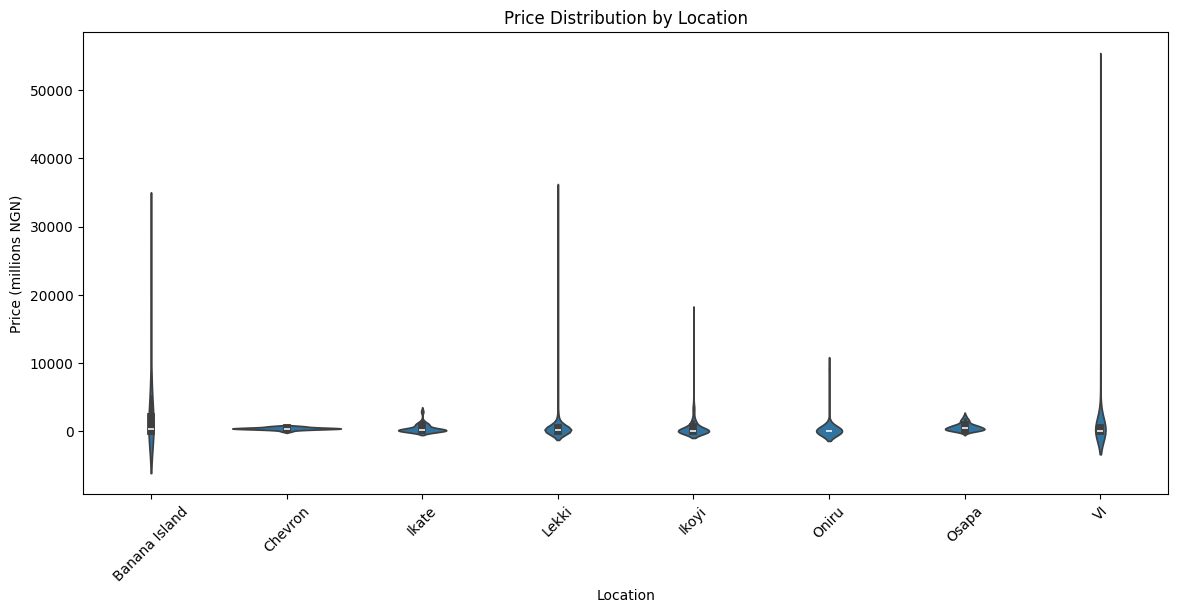

In [17]:
import seaborn as sns
fig = plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='location', y='price(millions_NGN)')
plt.title('Price Distribution by Location')
plt.xlabel('Location')
plt.ylabel('Price (millions NGN)')
plt.xticks(rotation=45)
plt.show()

<Figure size 1200x600 with 0 Axes>

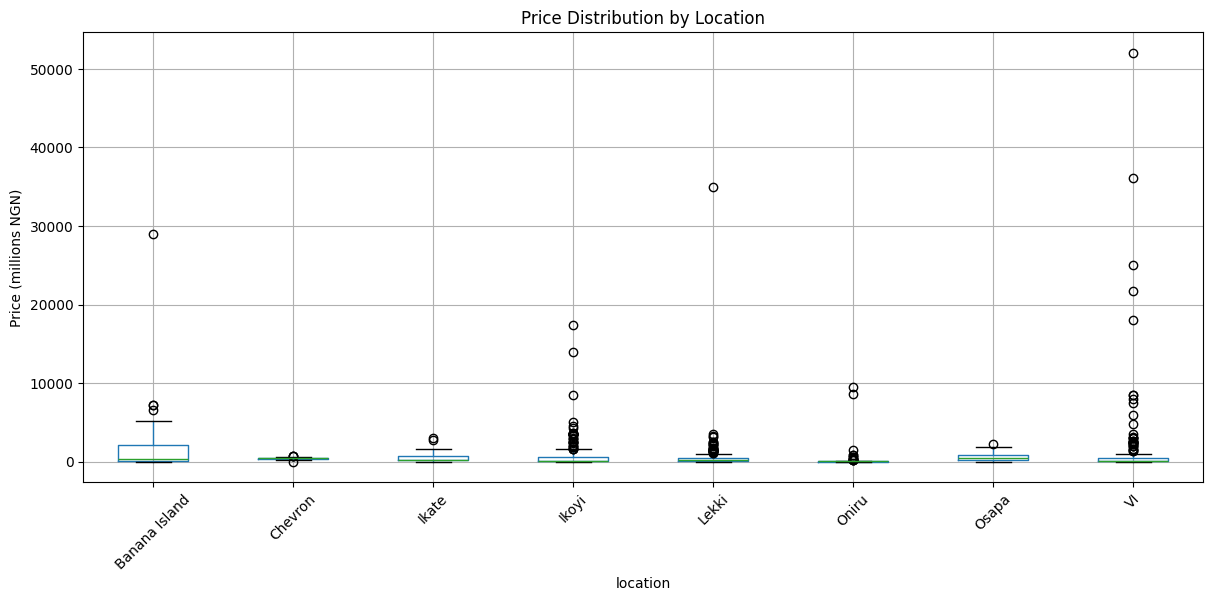

In [16]:
fig = plt.figure(figsize=(12, 6))
df.boxplot(column='price(millions_NGN)', by='location', figsize=(14, 6))
plt.title('Price Distribution by Location')
plt.suptitle('')  # Remove default title
plt.ylabel('Price (millions NGN)')
plt.xticks(rotation=45)
plt.show()